# 03 – Clustering und biologische Plausibilität

**Frage:** Wie unterscheiden sich K-Means, hierarchisches Ward-Clustering und Leiden bei der Beschreibung biologischer Zellgruppen? Wir vergleichen ein kleines festes Parameterraster geometrisch und prüfen anschließend die Markerprofile der ausgewählten Lösungen.

Es werden dieselben **10.000 `gated_alive`-Zellen, 500 je Spender**, wie in Aufgabe 2 unabhängig neu geladen. Original-Event-IDs, 37 geordnete Marker, `arcsinh(x/5)` und Standardisierung bleiben identisch. Alle 20 Spender gehen ausdrücklich nur in diese rein explorative Analyse ein; sie ist keine Validierung auf unabhängigen Spendern. Aufgabe 4, dessen Scaler, Modelle und Ergebnisse werden nicht verwendet oder verändert.

**Biologischer Bezug:** Horowitz et al. beschreiben in der ursprünglichen Datensatzpublikation grobe PBMC-Gruppen wie NK-, CD4-/CD8-T-, B- und myeloide Zellen, zugleich aber sehr vielfältige NK-Phänotypen. Wenige grobe Cluster können diese gesamte Vielfalt nicht rekonstruieren. Der bereitgestellte Benchmark umfasst 20 Spender; die Originalstudie beschreibt 22 Personen. Wir erfinden keine fehlenden Zelltyp-Labels oder zusätzlichen Spender. [Originalpublikation](https://pmc.ncbi.nlm.nih.gov/articles/3918221/)

In [1]:
from pathlib import Path
import sys
import hashlib
import importlib.metadata as package_metadata
import json
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from threadpoolctl import threadpool_limits

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "task23_analysis.py").exists())
sys.path.insert(0, str(PROJECT_ROOT))
from src.task23_analysis import (
    load_exploratory_data, projection_configs, fit_projection, fit_clusterings,
    silhouette_evaluation, select_clusterings, cluster_profiles,
)
TABLE_DIR, FIGURE_DIR = PROJECT_ROOT / "results" / "tables", PROJECT_ROOT / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="white", context="notebook")
versions = {p: package_metadata.version(p) for p in
            ["numpy", "pandas", "scipy", "scikit-learn", "umap-learn", "numba", "flowkit", "igraph", "leidenalg", "matplotlib", "seaborn"]}
cells, transformed, scaled, scaler, provenance = load_exploratory_data(PROJECT_ROOT)
assert cells.cell_id.is_unique and scaled.shape == (10_000, 37)
assert cells.groupby("sample_id").size().eq(500).all()
display(pd.Series(versions, name="Paketversion"))
print("Explorative Eingabe:", scaled.shape, "· gated_alive · 20 gleich gewichtete Spender")

numpy            2.5.2
pandas           2.3.3
scipy           1.18.0
scikit-learn     1.9.0
umap-learn      0.5.12
numba           0.67.0
flowkit          1.3.2
igraph           1.0.0
leidenalg       0.12.0
matplotlib      3.11.1
seaborn         0.13.2
Name: Paketversion, dtype: object

Explorative Eingabe: (10000, 37) · gated_alive · 20 gleich gewichtete Spender


## 1. Drei Verfahren auf denselben 37-dimensionalen Zellen

Alle Cluster werden im standardisierten **37D-Markerraum** gefittet. Zweidimensionale Koordinaten dienen später ausschließlich der Darstellung. CMV-Labels sind weder Eingabe noch Zelltyp-Groundtruth.

| Verfahren | Vorab festgelegtes Raster | Konstante Einstellungen |
|---|---|---|
| K-Means | 6, 10, 14 Cluster | 20 Initialisierungen, höchstens 300 Iterationen, Seed 42; euklidische Geometrie |
| Hierarchisch: Ward | Schnitte bei exakt 6, 10, 14 Clustern | Ein vollständiger Ward-Baum im 37D-Raum; euklidische Distanz, keine Graphbeschränkung |
| Leiden | Auflösung 0,5; 1,0; 1,5 | Ungewichteter, ungerichteter Uniongraph der 15 nächsten Nachbarn; `RBConfigurationVertexPartition`, Seed 42, Iterationen bis keine Qualitätsverbesserung |

Für den Leiden-Uniongraph reicht eine gerichtete Nachbarschaftsbeziehung aus, um eine ungerichtete Kante aufzunehmen. Selbstkanten und Mehrfachkanten werden ausgeschlossen. Diese bewusste einfache Graphwahl ist dokumentiert und verwendet keine implizite Scanpy-Vorverarbeitung. Auflösung ist keine vorgegebene Clusterzahl; die tatsächlich entstandene Zahl wird berichtet. Sonstige Parameter behalten die Defaults der dokumentierten Paketversionen.

In [2]:
started = perf_counter()
with threadpool_limits(limits=1):
    partitions, configurations = fit_clusterings(scaled)
fit_seconds = perf_counter() - started
parameter_table = pd.DataFrame([
    {"variant": c["variant"], "method": c["method"], "parameters": json.dumps(c["params"], sort_keys=True)}
    for c in configurations
])
assert len(partitions) == 9
assert all(len(labels) == len(cells) for labels in partitions.values())
display(parameter_table)
print(f"Neun Partitionen in {fit_seconds:.1f} s berechnet.")

,variant,method,parameters
0,kmeans_k6,K-Means,"{""max_iter"": 300, ""n_clusters"": 6, ""n_init"": 2..."
1,kmeans_k10,K-Means,"{""max_iter"": 300, ""n_clusters"": 10, ""n_init"": ..."
2,kmeans_k14,K-Means,"{""max_iter"": 300, ""n_clusters"": 14, ""n_init"": ..."
3,ward_k6,Ward,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_..."
4,ward_k10,Ward,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_..."
5,ward_k14,Ward,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_..."
6,leiden_r0.5,Leiden,"{""graph"": ""unweighted undirected kNN union"", ""..."
7,leiden_r1.0,Leiden,"{""graph"": ""unweighted undirected kNN union"", ""..."
8,leiden_r1.5,Leiden,"{""graph"": ""unweighted undirected kNN union"", ""..."


Neun Partitionen in 4.6 s berechnet.


## 2. Quantitatives Kriterium: spendergemittelte Silhouette

Für jede Zelle misst $s=(b-a)/\max(a,b)$ die mittlere Distanz $a$ zu anderen Zellen des eigenen Clusters relativ zur kleinsten mittleren Distanz $b$ zu einem anderen Cluster. Werte nahe 1 sprechen für kompakte, getrennte Gruppen; negative Werte für geometrische Überschneidung. Dieses Kriterium bevorzugt kompakte Gruppen und kann biologisch sinnvolle nichtkugelförmige Leiden-Gruppen benachteiligen.

Wir ziehen **einmal dieselben 100 Zellen je Spender** aus der gemeinsamen Stichprobe (`default_rng(43 + sortierter Spenderindex)`) und berechnen die Silhouette auf dieser induzierten 2.000-Zell-Stichprobe. Das ist eine ausdrücklich bezeichnete Approximation: Auch die Distanzmittel verwenden nur diese Zellen, nicht alle 10.000 Referenzzellen. Fehlt darin ein Cluster irgendeiner Lösung, wird für **alle neun** Lösungen auf die vollständigen 10.000 Zellen umgestellt. Die Tabelle und Provenienz zeigen den tatsächlich verwendeten Umfang.

Wir mitteln erst je Spender und dann gleich gewichtet über alle 20 Spender. Ein einzelner Cluster beziehungsweise ausschließlich Einzelcluster ergeben keine definierte Silhouette und werden mit Begründung ausgeschlossen. Einzelzellencluster in ansonsten gültigen Lösungen bekommen gemäß scikit-learn Silhouette 0. Je Verfahren gewinnt die höchste Silhouette; bei Gleichstand innerhalb `1e-12` folgen weniger tatsächliche Cluster, dann Rasterreihenfolge. Es erfolgt kein nachträgliches Erweitern des Rasters, um schönere Bilder zu erhalten. [Definition und Implementierung](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_samples.html)

Clusterzahl, kleinster Cluster und Einzelclusterzahl beziehen sich auf die vollständige Fit-Stichprobe. Nur die Silhouette verwendet gegebenenfalls die kleinere Auswertungsstichprobe.

In [3]:
with threadpool_limits(limits=1):
    summary, donor_silhouettes, evaluation_indices, full_fallback = silhouette_evaluation(
        scaled, cells, partitions)
summary = parameter_table.merge(summary, on="variant", validate="one_to_one", sort=False)
selected_variants = select_clusterings(summary)
summary["selected"] = summary.variant.isin(selected_variants)
display(summary.drop(columns="parameters").round(4))
print("Auswertungszellen:", len(evaluation_indices), "· fehlende Cluster lösten Vollauswertung aus:", full_fallback)
recommendations = summary.loc[summary.selected, ["method", "variant", "parameters", "n_clusters", "silhouette"]].copy()
display(recommendations.rename(columns={"method": "Verfahren", "variant": "Gewählte Variante",
                                       "parameters": "Parameter", "n_clusters": "Clusterzahl", "silhouette": "Silhouette"}))

,variant,method,n_clusters,min_cluster_size,singleton_clusters,evaluation_cells,silhouette,invalid_reason,selected
0,kmeans_k6,K-Means,6,262,0,2000,0.0793,,True
1,kmeans_k10,K-Means,10,244,0,2000,0.0729,,False
2,kmeans_k14,K-Means,14,177,0,2000,0.0664,,False
3,ward_k6,Ward,6,247,0,2000,0.0467,,False
4,ward_k10,Ward,10,216,0,2000,0.0375,,False
5,ward_k14,Ward,14,216,0,2000,0.0489,,True
6,leiden_r0.5,Leiden,7,244,0,2000,0.0665,,False
7,leiden_r1.0,Leiden,11,152,0,2000,0.0671,,True
8,leiden_r1.5,Leiden,18,115,0,2000,0.0229,,False


Auswertungszellen: 2000 · fehlende Cluster lösten Vollauswertung aus: False


,Verfahren,Gewählte Variante,Parameter,Clusterzahl,Silhouette
0,K-Means,kmeans_k6,"{""max_iter"": 300, ""n_clusters"": 6, ""n_init"": 2...",6,0.079322
5,Ward,ward_k14,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_...",14,0.048859
7,Leiden,leiden_r1.0,"{""graph"": ""unweighted undirected kNN union"", ""...",11,0.067127


## 3. Gleiche UMAP-Basiskarte für alle drei Lösungen

Die UMAP mit 15 Nachbarn und `min_dist=0.1` wird mit identischer Konfiguration wie in Aufgabe 2 selbst neu berechnet. Dadurch besteht keine Abhängigkeit von dessen Kernelzustand oder alten CSV-Dateien. Diese Baseline war dort zugleich die beste untersuchte UMAP-Einstellung nach 15-Nachbarn-Jaccard; sie wird hier nicht anhand der Clusterbilder nachoptimiert.

Die drei Panels zeigen dieselben Zellen an exakt denselben Positionen. **Farben und Clusternummern gelten nur innerhalb eines Verfahrens:** Cluster 0 bei K-Means ist nicht automatisch Cluster 0 bei Ward oder Leiden. Die anschließenden Markerprofile erlauben die biologische Gegenüberstellung.

/home/gregor/projects/Group-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


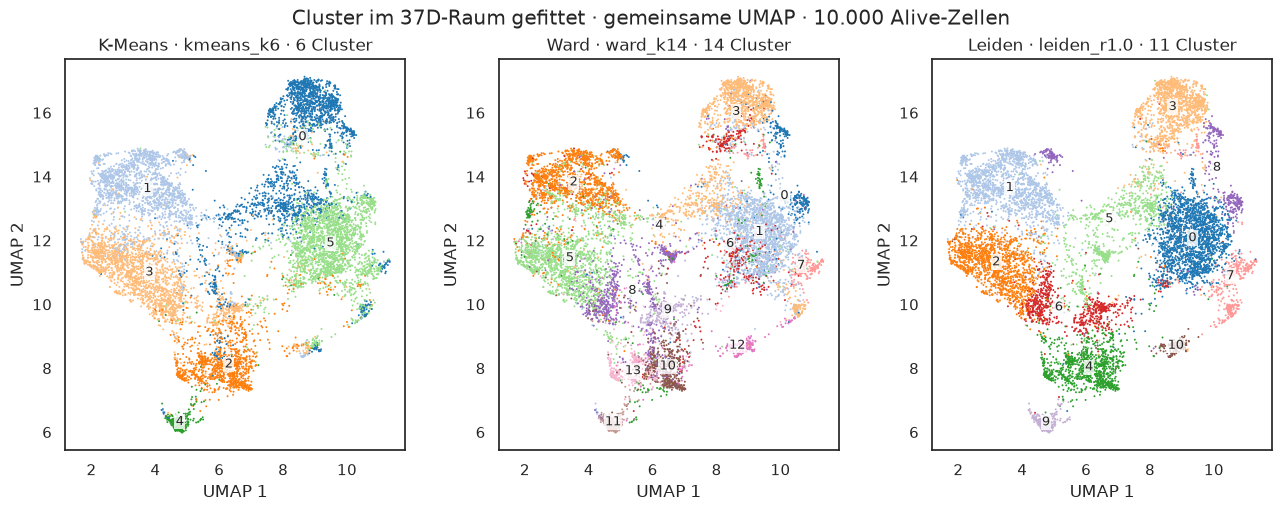

In [4]:
umap_config = next(c for c in projection_configs() if c["variant"] == "umap_n15_d0.1")
with threadpool_limits(limits=1):
    coordinates, _ = fit_projection(scaled, umap_config)
plot_order = np.random.default_rng(42).permutation(len(cells))
fig, axes = plt.subplots(1, 3, figsize=(13, 5), layout="constrained")
for axis, variant in zip(axes, selected_variants):
    labels = partitions[variant]
    row = summary.set_index("variant").loc[variant]
    palette = sns.color_palette("tab20", n_colors=len(np.unique(labels)))
    axis.scatter(*coordinates[plot_order].T, s=2, c=np.asarray(palette)[labels[plot_order]],
                 linewidths=0, rasterized=True)
    for cluster in np.unique(labels):
        position = np.median(coordinates[labels == cluster], axis=0)
        axis.text(*position, str(cluster), ha="center", va="center", fontsize=9,
                  bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1))
    axis.set(title=f"{row['method']} · {variant} · {row['n_clusters']} Cluster",
             xlabel="UMAP 1", ylabel="UMAP 2", aspect="equal")
fig.suptitle("Cluster im 37D-Raum gefittet · gemeinsame UMAP · 10.000 Alive-Zellen")
fig.savefig(FIGURE_DIR / "task3_cluster_maps.png", dpi=180)
plt.show()

## 4. Markerprofile und Spenderabdeckung

Für jeden Cluster berechnen wir zunächst den Median der arcsinh-transformierten Marker **je vertretenem Spender**, danach den Median über diese Spender. Ein fehlender Cluster bei einem Spender wird nicht als Markerexpression 0 eingesetzt. So dominiert ein Spender mit vielen Clusterzellen nicht das Profil; allerdings ist ein Profil aus wenigen Zellen ungenauer. Deshalb stehen Zellzahl, Spenderabdeckung und der größte Anteil eines einzelnen Spenders am Cluster daneben. Abdeckung bedeutet mindestens eine gezogene Clusterzelle und ist kein Stabilitätsnachweis.

Alle 37 Marker werden exportiert. Die kompakte Heatmap zeigt zwölf vorab festgelegte Marker für grobe Linien und NK-Phänotypen. Die aggregierten arcsinh-Profile werden zur Darstellung mit **demselben Explorations-Scaler** in z-Werte umgerechnet; es gibt keine neue Skalierung pro Verfahren oder Cluster. Höhere Farbe bedeutet relativ höhere Expression dieses Markers, keine validierte Positivitätsgrenze.

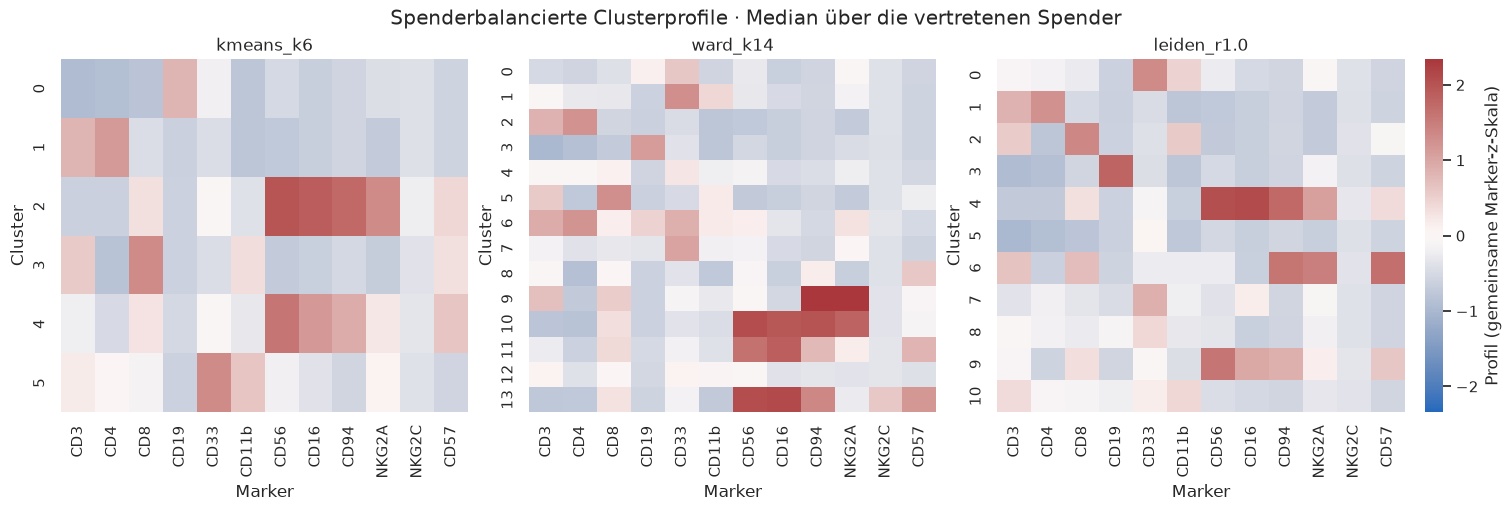

,cluster,cell_count,donor_coverage,dominant_donor_share,variant
0,0,2268,20,0.085,kmeans_k6
1,1,1902,20,0.101,kmeans_k6
2,2,1153,20,0.109,kmeans_k6
3,3,2063,20,0.084,kmeans_k6
4,4,262,20,0.134,kmeans_k6
5,5,2352,20,0.090,kmeans_k6
6,0,334,20,0.096,ward_k14
7,1,1920,20,0.091,ward_k14
8,2,1310,20,0.106,ward_k14
9,3,1522,20,0.096,ward_k14


,variant,cluster,CD3,CD4,CD8,CD19,CD33,CD11b,CD56,CD16,CD94,NKG2A,NKG2C,CD57
0,kmeans_k6,0,1.56,-0.03,0.51,1.64,1.90,-0.07,0.24,-0.05,-0.07,0.25,-0.08,-0.08
1,kmeans_k6,1,4.80,2.51,1.15,-0.06,1.43,-0.08,-0.08,-0.06,-0.08,-0.07,-0.08,-0.07
2,kmeans_k6,2,2.13,0.28,2.45,-0.04,2.11,0.29,3.48,3.95,2.93,2.41,0.05,1.38
3,kmeans_k6,3,4.36,0.03,4.17,-0.04,1.45,1.01,-0.03,-0.04,-0.02,-0.05,-0.06,1.21
4,kmeans_k6,4,2.89,0.45,2.37,0.05,2.13,0.38,2.96,2.79,1.88,1.09,-0.03,1.65
5,kmeans_k6,5,3.64,1.09,1.66,-0.04,4.58,1.26,0.63,0.42,-0.05,0.89,-0.06,-0.06
6,ward_k14,0,2.37,0.34,1.21,0.83,3.31,0.13,0.51,-0.02,-0.08,0.78,-0.06,-0.06
7,ward_k14,1,3.16,0.73,1.39,-0.05,4.49,1.08,0.50,0.22,-0.06,0.60,-0.07,-0.07
8,ward_k14,2,4.85,2.64,0.95,-0.06,1.40,-0.07,-0.08,-0.06,-0.09,-0.07,-0.07,-0.07
9,ward_k14,3,1.48,-0.02,0.70,2.02,1.58,-0.07,0.19,-0.05,-0.08,0.21,-0.08,-0.08


In [5]:
profile_rows, count_rows, donor_profile_rows, donor_count_rows = [], [], [], []
for variant in selected_variants:
    profiles, counts, donor_profiles, donor_counts = cluster_profiles(transformed, cells, partitions[variant])
    profile_rows.append(profiles.reset_index().assign(variant=variant))
    count_rows.append(counts.reset_index().assign(variant=variant))
    donor_profile_rows.append(donor_profiles.reset_index().assign(variant=variant))
    donor_count_rows.append(donor_counts.rename_axis(columns="sample_id").stack().rename("cell_count").reset_index().assign(variant=variant))
profiles_table = pd.concat(profile_rows, ignore_index=True)
counts_table = pd.concat(count_rows, ignore_index=True)
donor_profiles_table = pd.concat(donor_profile_rows, ignore_index=True)
donor_counts_table = pd.concat(donor_count_rows, ignore_index=True)
heat_markers = ["CD3", "CD4", "CD8", "CD19", "CD33", "CD11b", "CD56", "CD16", "CD94", "NKG2A", "NKG2C", "CD57"]
scaled_profiles = pd.DataFrame(scaler.transform(profiles_table[transformed.columns]), columns=transformed.columns)
scaled_profiles[["variant", "cluster"]] = profiles_table[["variant", "cluster"]]
color_limit = max(1, float(np.abs(scaled_profiles[heat_markers].to_numpy()).max()))
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
for axis, variant in zip(axes, selected_variants):
    matrix = scaled_profiles.loc[scaled_profiles.variant == variant].set_index("cluster")[heat_markers]
    sns.heatmap(matrix, cmap="vlag", vmin=-color_limit, vmax=color_limit, center=0, ax=axis,
                cbar=axis is axes[-1], cbar_kws={"label": "Profil (gemeinsame Marker-z-Skala)"})
    axis.set(title=variant, xlabel="Marker", ylabel="Cluster")
fig.suptitle("Spenderbalancierte Clusterprofile · Median über die vertretenen Spender")
fig.savefig(FIGURE_DIR / "task3_marker_profiles.png", dpi=180)
plt.show()
display(counts_table.round(3))
display(profiles_table[["variant", "cluster", *heat_markers]].round(2))

## 5. Biologische Einordnung und Antwort auf die Aufgabenfrage

Die Annotation wird anhand der gemeinsam betrachteten tatsächlichen Markerprofile erstellt. CD3 zusammen mit CD4/CD8 unterstützt T-kompatible, CD19 B-kompatible und CD33/CD11b myeloid-kompatible Profile. Relativ niedrige Linienmarker zusammen mit CD56/CD16 und weiteren NK-Rezeptoren unterstützen NK-kompatible Profile. Kein einzelner Marker wird als erfundenes hartes Gate verwendet. CD57/NKG2C allein beweisen weder NK-Identität noch einen CMV-Zusammenhang.

Die geometrische Empfehlung wird von dieser biologischen Bewertung getrennt. Silhouette liefert keine unabhängige Validierung der Zelltypen. Die verfügbaren Profile erlauben vorsichtige Interpretation, aber keinen Vergleich mit nicht vorhandenen manuell gegateten Zelltyp-Referenzlabels.

In [6]:
# Manuelle, vorsichtige Einordnung der tatsächlich inspizierten 37-Marker-Profile.
# Die Bindung an Daten und Partitionen verhindert still veraltete Clusterannotation.
annotation_digest = hashlib.sha256(provenance["selected_data_sha256"].encode())
for variant in selected_variants:
    annotation_digest.update(variant.encode())
    annotation_digest.update(np.asarray(partitions[variant], dtype="<i8").tobytes())
expected_annotation_digest = "16b1d3affa4cbe2fe4928576b2a9d8d87d7c42893bb576773ec6ba1152afd68e"
if annotation_digest.hexdigest() != expected_annotation_digest:
    raise ValueError("Daten oder Partitionen geändert: manuelle Markerannotation vor Wiederverwendung neu prüfen.")
annotation_notes = {
    "kmeans_k6": [
        (0, "B-kompatibel, breit", "CD19/HLA-DR relativ erhöht; CD3 niedriger als in T-Profilen; mögliche Mischung."),
        (1, "CD4-T-kompatibel", "CD3/CD4/CD127 erhöht; CD19 und NK-Marker niedrig."),
        (2, "NK-kompatibel", "CD56/CD16/CD94/NKp46 erhöht; CD3 niedriger als in T-Profilen."),
        (3, "CD8-T-kompatibel", "CD3/CD8 erhöht; CD56/CD16 niedrig; NKG2D/CD57 teilweise erhöht."),
        (4, "NK-kompatibel, KIR-reich", "CD56/CD16 sowie 3DL1 und 3DL1-S1 stark erhöht; CD3 intermediär, Mischung nicht ausgeschlossen."),
        (5, "Myeloid-kompatibel, breit", "CD33/HLA-DR/ILT2-CD85j erhöht; CD19 niedrig; keine feinere Linienzuordnung."),
    ],
    "ward_k14": [
        (0, "Gemischt/unklar, CD25-reich", "CD25/HLA-DR erhöht, CD19 und CD33 zugleich messbar; kein eindeutiges Linienprofil."),
        (1, "Myeloid-kompatibel", "CD33/HLA-DR/ILT2-CD85j erhöht; CD19 niedrig."),
        (2, "CD4-T-kompatibel", "CD3/CD4/CD127 erhöht; CD19 und NK-Marker niedrig."),
        (3, "B-kompatibel", "CD19/HLA-DR erhöht; CD3 niedriger als in T-Profilen."),
        (4, "Gemischt/unklar, NKp44-reich", "NKp44 erhöht, jedoch kein klares gemeinsames CD56/CD16/NKp46-Profil."),
        (5, "CD8-T-kompatibel", "CD3/CD8 erhöht; CD19/CD56/CD16 niedrig."),
        (6, "Gemischt, CD4-T-kompatibler Anteil", "CD3/CD4/CD127 erhöht, zugleich CD19/CD33/HLA-DR messbar; keine reine T-Gruppe behauptet."),
        (7, "Myeloid-kompatibel, CD117-reich", "CD33/HLA-DR/ILT2-CD85j und CD117 erhöht; keine Stammzellzuordnung aus CD117 allein."),
        (8, "Gemischt/unklar", "CD3 intermediär, CD57/NKp30 erhöht; keine klare T-/NK-Abgrenzung."),
        (9, "T-kompatibel mit NK-Rezeptoren", "CD3/CD8 sowie CD94/NKG2A erhöht; CD16 niedrig; keine NKT-Identität ableitbar."),
        (10, "NK-kompatibel, NKG2A-reich", "CD56/CD16/NKp46/CD94/NKG2A erhöht; CD3 relativ niedrig."),
        (11, "NK-kompatibel, KIR-reich", "CD56/CD16 sowie 3DL1 und 3DL1-S1 erhöht; CD3 intermediär, Mischung nicht ausgeschlossen."),
        (12, "Gemischt/unklar, TRAIL-reich", "TRAIL stark erhöht, übrige Linienmarker ohne eindeutige Kombination."),
        (13, "NK-kompatibel, CD57-reich", "CD56/CD16/NKp46 und CD57 erhöht, NKG2A niedriger als Cluster 10; keine CMV-Zuordnung."),
    ],
    "leiden_r1.0": [
        (0, "Myeloid-kompatibel", "CD33/HLA-DR/ILT2-CD85j erhöht; CD19 niedrig."),
        (1, "CD4-T-kompatibel", "CD3/CD4/CD127 erhöht; CD19 und NK-Marker niedrig."),
        (2, "CD8-T-kompatibel", "CD3/CD8 erhöht; CD56/CD16 niedrig."),
        (3, "B-kompatibel", "CD19/HLA-DR deutlicher erhöht als im breiten K-Means-Cluster 0; CD3 relativ niedrig."),
        (4, "NK-kompatibel", "CD56/CD16/CD94/NKp46 erhöht; CD3 niedriger als in T-Profilen."),
        (5, "Unklar, schwaches Linienprofil", "CD3/CD19/CD56/CD16 niedrig; kein eindeutiger Zelltyp aus diesen Markern ableitbar."),
        (6, "T-kompatibel mit NK-Rezeptoren", "CD3/CD8/CD57 sowie CD94/NKG2A erhöht; CD16 niedrig; keine NKT-Identität ableitbar."),
        (7, "Myeloid-kompatibel, CD117-reich", "CD33/HLA-DR/ILT2-CD85j und CD117 erhöht; keine feinere Linienzuordnung."),
        (8, "Gemischt/unklar, CD25-reich", "CD25/HLA-DR erhöht, CD3/CD19/CD33 intermediär; keine eindeutige Linie."),
        (9, "NK-kompatibel, KIR-reich", "CD56/CD16 sowie 3DL1 und 3DL1-S1 erhöht; CD3 intermediär, Mischung nicht ausgeschlossen."),
        (10, "Gemischt/unklar, TRAIL-reich", "TRAIL stark erhöht, CD3 messbar, übrige Linienmarker ohne eindeutige Kombination."),
    ],
}
annotations = pd.DataFrame([
    dict(variant=variant, cluster=cluster, annotation=annotation, evidence=evidence)
    for variant, rows in annotation_notes.items() for cluster, annotation, evidence in rows
])
assert set(zip(annotations.variant, annotations.cluster)) == set(zip(profiles_table.variant, profiles_table.cluster))
assert not annotations.duplicated(["variant", "cluster"]).any()
display(annotations.merge(counts_table, on=["variant", "cluster"], validate="one_to_one"))

,variant,cluster,annotation,evidence,cell_count,donor_coverage,dominant_donor_share
0,kmeans_k6,0,"B-kompatibel, breit",CD19/HLA-DR relativ erhöht; CD3 niedriger als ...,2268,20,0.084656
1,kmeans_k6,1,CD4-T-kompatibel,CD3/CD4/CD127 erhöht; CD19 und NK-Marker niedrig.,1902,20,0.100946
2,kmeans_k6,2,NK-kompatibel,CD56/CD16/CD94/NKp46 erhöht; CD3 niedriger als...,1153,20,0.109280
3,kmeans_k6,3,CD8-T-kompatibel,CD3/CD8 erhöht; CD56/CD16 niedrig; NKG2D/CD57 ...,2063,20,0.084343
4,kmeans_k6,4,"NK-kompatibel, KIR-reich",CD56/CD16 sowie 3DL1 und 3DL1-S1 stark erhöht;...,262,20,0.133588
5,kmeans_k6,5,"Myeloid-kompatibel, breit",CD33/HLA-DR/ILT2-CD85j erhöht; CD19 niedrig; k...,2352,20,0.089711
6,ward_k14,0,"Gemischt/unklar, CD25-reich","CD25/HLA-DR erhöht, CD19 und CD33 zugleich mes...",334,20,0.095808
7,ward_k14,1,Myeloid-kompatibel,CD33/HLA-DR/ILT2-CD85j erhöht; CD19 niedrig.,1920,20,0.090625
8,ward_k14,2,CD4-T-kompatibel,CD3/CD4/CD127 erhöht; CD19 und NK-Marker niedrig.,1310,20,0.106107
9,ward_k14,3,B-kompatibel,CD19/HLA-DR erhöht; CD3 niedriger als in T-Pro...,1522,20,0.095926


**Ergebnis:** Nach dem vorab festgelegten geometrischen Kriterium werden K-Means mit 6 Clustern (Silhouette 0,0793), Ward mit 14 Clustern (0,0489) und Leiden mit Auflösung 1,0 und 11 Clustern (0,0671) ausgewählt. Sämtliche absoluten Silhouetten sind niedrig: Die standardisierte Markerstruktur ist nur schwach in kompakte, klar getrennte Gruppen zerlegt. Leiden mit Auflösung 0,5 und 7 Clustern erreicht bereits 0,0665. Der kleine Unterschied von etwa 0,0006 belegt keinen belastbaren Vorteil der feineren Lösung; Sampling-/Seed-Stabilität wurde hier nicht untersucht.

**Welche Lösung bildet Zelltypen am besten ab?** Alle drei Lösungen enthalten nachvollziehbare CD4-T-, CD8-T-, B-, myeloid- und NK-kompatible Profile. K-Means bietet die kompakteste Übersicht und den höchsten geometrischen Wert, fasst aber insbesondere die breite B-kompatible Gruppe stark zusammen. Leiden trennt ein deutlicheres CD19/HLA-DR-Profil und ein CD3/CD8/CD57/CD94/NKG2A-geprägtes Profil ab; daneben bleiben mehrere Gruppen unklar. Ward zeigt zusätzlich eine plausible NK-Unterteilung mit relativ hohem NKG2A gegenüber relativ hohem CD57, produziert aber bei 14 Clustern auch mehrere gemischte beziehungsweise nur durch einzelne Marker charakterisierte Gruppen. Mehr Cluster bedeuten deshalb nicht automatisch mehr bestätigte Zelltypen.

Für eine kompakte Darstellung im Bericht ist **K-Means mit 6 Clustern eine nachvollziehbare Ausgangslösung**; Leiden ergänzt eine feinere Markerübersicht, Ward zeigt mögliche NK-Unterstruktur. Eine eindeutige biologische Überlegenheit ist ohne unabhängige Zelltypannotation aus diesen Ergebnissen nicht belegt. Diese Schlussfolgerung trennt geometrische Auswahl und biologische Plausibilität ausdrücklich.

Die ausgewählten Cluster werden in 18 bis 20 Spendern beobachtet; kein einzelner Spender stellt mehr als rund 19 % der Zellen eines Clusters. Das spricht gegen eine ausschließlich von einem Spender getragene Gruppe, ersetzt jedoch keine Stabilitätsanalyse. Seltene Gruppen, kleine Clusteranteile und einzelne Rezeptorprofile bleiben durch das Sampling und die fehlende Zelltyp-Groundtruth begrenzt.

## 6. Exporte und Grenzen

Die vollständigen neun Clusterzuweisungen bleiben über Zell-IDs nachvollziehbar. Exportiert werden außerdem alle Parameter, spenderweise und gemittelte Silhouetten, Auswahl, Profile und Spenderabdeckung. Die Provenienz dokumentiert die tatsächliche Auswertungsstichprobe. Alle Analysen sind explorativ; kein CMV-Test, keine Generalisierung auf neue Spender, keine Aussage über seltene Populationen außerhalb der gezogenen Stichprobe.

Für den fünfseitigen Gesamtbericht eignen sich wenige repräsentative Kartenpanels und eine kleine Tabelle der drei ausgewählten Lösungen. Die neun Parameterlösungen und vollständigen Markerprofile bleiben im Notebook beziehungsweise Export.

In [7]:
assignments = cells.copy()
for variant, labels in partitions.items():
    assignments[variant] = labels
assignments.to_csv(TABLE_DIR / "task3_assignments.csv", index=False)
cells.assign(component_1=coordinates[:, 0].astype(np.float64), component_2=coordinates[:, 1].astype(np.float64)).to_csv(TABLE_DIR / "task3_umap.csv", index=False)
summary.to_csv(TABLE_DIR / "task3_cluster_comparison.csv", index=False)
recommendations.to_csv(TABLE_DIR / "task3_recommendations.csv", index=False)
donor_silhouettes.to_csv(TABLE_DIR / "task3_donor_silhouettes.csv", index=False)
profiles_table.to_csv(TABLE_DIR / "task3_marker_profiles.csv", index=False)
counts_table.to_csv(TABLE_DIR / "task3_cluster_counts.csv", index=False)
donor_profiles_table.to_csv(TABLE_DIR / "task3_donor_marker_profiles.csv", index=False)
donor_counts_table.to_csv(TABLE_DIR / "task3_donor_cluster_counts.csv", index=False)
annotations.to_csv(TABLE_DIR / "task3_annotations.csv", index=False)
provenance.update(versions=versions, configurations=configurations, umap_configuration=umap_config,
                  silhouette=dict(metric="euclidean", requested_cells_per_donor=100,
                                  seed=43, missing_cluster_full_fallback=full_fallback,
                                  evaluation_cell_ids=cells.iloc[evaluation_indices].cell_id.tolist(),
                                  aggregation="cell mean per donor, then equal donor mean"),
                  selected_variants=selected_variants, heatmap_markers=heat_markers,
                  annotation_data_partition_sha256=annotation_digest.hexdigest(),
                  profile_aggregation="median within donor/cluster, then median across represented donors; absent donors excluded",
                  thread_limit=1, implementation_sha256=hashlib.sha256(
                      (PROJECT_ROOT / "src" / "task23_analysis.py").read_bytes()).hexdigest())
(TABLE_DIR / "task3_provenance.json").write_text(json.dumps(provenance, indent=2, ensure_ascii=False), encoding="utf-8")
print("Neun Partitionen, geometrischer Vergleich und biologische Profilgrundlage exportiert.")

Neun Partitionen, geometrischer Vergleich und biologische Profilgrundlage exportiert.


## Quellen

- [Horowitz et al. (2013), Originalpublikation des Datensatzes](https://pmc.ncbi.nlm.nih.gov/articles/3918221/): breite PBMC-Gruppen und große NK-Phänotypvielfalt.
- [scikit-learn: Silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_samples.html): Definition und Voraussetzungen.
- [SciPy: hierarchisches Linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html): Ward und euklidische Distanz.
- [leidenalg: Partition und Auflösung](https://leidenalg.readthedocs.io/en/latest/reference.html): `RBConfigurationVertexPartition` und Parameter.